Loaded interaction_effects_mean.npy from shap_outputs
Using 31 features: ['Household income', 'Age', 'Gender', 'Education level', 'Employment status', 'Neighborhood type', 'Work_study', 'Housework', 'Personal affair', 'Leisure', 'Travel', 'Transportation', 'Residence', 'Industry', 'Company', 'Shopping', 'Restaurant', 'Life service', 'Education culture', 'Entertainment', 'Sport_fitness', 'Recreation_tourism', 'Healthcare', 'Workday', 'Time hour', 'Mobility status', 'Time inflexibility', 'Being neighborhood', 'POI density', 'POI diversity', 'Tree height']

Top 5 interacting variables for each feature:

Household income:
  1. Work_study: 0.000173
  2. Shopping: 0.000112
  3. POI density: 0.000109
  4. Transportation: 0.000097
  5. Recreation_tourism: 0.000083

Age:
  1. Education culture: 0.000174
  2. Company: 0.000135
  3. Being neighborhood: 0.000125
  4. Tree height: 0.000122
  5. Restaurant: 0.000114

Gender:
  1. Industry: 0.000010
  2. Being neighborhood: 0.000008
  3. Life service

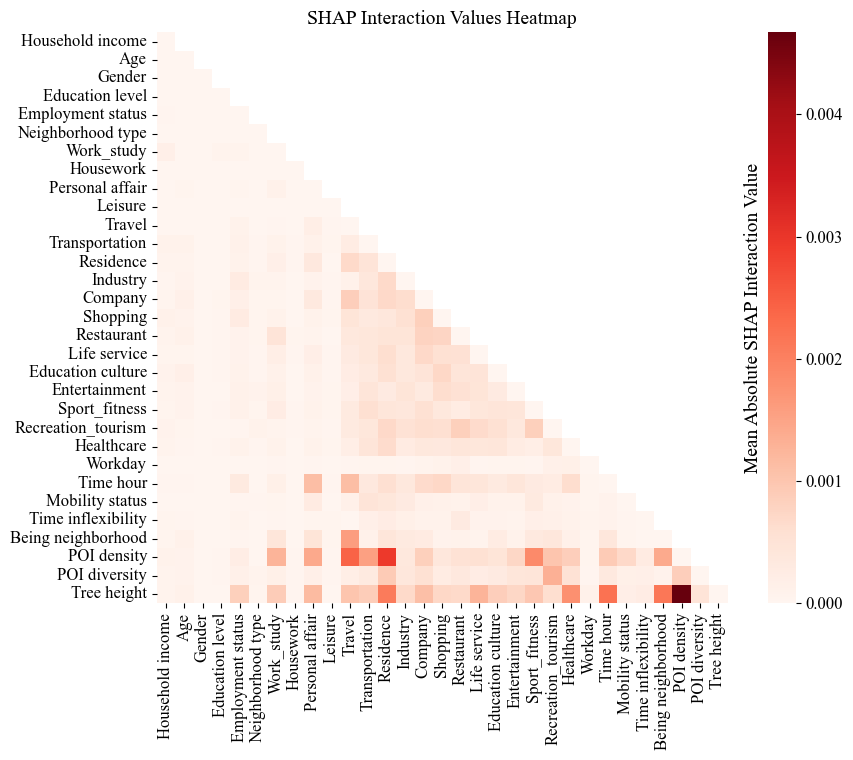

In [9]:
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings


warnings.filterwarnings('ignore')


out_dir = 'shap_outputs'
os.makedirs(out_dir, exist_ok=True)


feature_names_display = [
    'Household income', 'Age', 'Gender', 'Education level', 'Employment status', 'Neighborhood type',
    'Work_study', 'Housework', 'Personal affair', 'Leisure', 'Travel', 'Transportation',
    'Residence', 'Industry', 'Company', 'Shopping', 'Restaurant', 'Life service',
    'Education culture', 'Entertainment', 'Sport_fitness', 'Recreation_tourism', 'Healthcare',
    'Workday', 'Time hour', 'Mobility status', 'Time inflexibility', 'Being neighborhood',
    'POI density', 'POI diversity', 'Tree height'
]

# Load interaction_effects_mean.npy
try:
    shap_interaction_values = np.load(os.path.join(out_dir, 'interaction_effects_mean.npy'))
    print(f"Loaded interaction_effects_mean.npy from {out_dir}")
except FileNotFoundError as e:
    print(f"Error: interaction_effects_mean.npy not found in {out_dir}. Please ensure the first code has run successfully: {str(e)}")
    raise
except Exception as e:
    print(f"Error loading interaction_effects_mean.npy: {str(e)}")
    raise


try:
    n_features = shap_interaction_values.shape[1]
    if len(feature_names_display) != n_features:
        raise ValueError(f"Length of ffeature_names_display ({len(feature_names_display)}) does not match interaction matrix shape ({n_features})")
    print(f"Using {n_features} features: {feature_names_display}")
except Exception as e:
    print(f"Error validating feature_names_display: {str(e)}")
    raise


try:
    mean_interaction_values = np.mean(np.abs(shap_interaction_values), axis=0)  # Shape: (n_features, n_features)
    np.fill_diagonal(mean_interaction_values, 0)  # Zero out diagonal (main effects)
    mask = np.triu(np.ones_like(mean_interaction_values, dtype=bool), k=1)  # Upper triangle mask
except Exception as e:
    print(f"Error computing mean interaction values or mask: {str(e)}")
    raise

# Find top five interacting variables for each feature
try:
    print("\nTop 5 interacting variables for each feature:")
    for i, feature in enumerate(feature_names_display):
        # Get interaction values for this feature (row i)
        interaction_row = mean_interaction_values[i, :]
        # Get indices of top 5 interactions (excluding self-interaction)
        top_indices = np.argsort(interaction_row)[::-1][:5]  # Descending order, top 5
        top_features = [feature_names_display[j] for j in top_indices]
        top_values = [interaction_row[j] for j in top_indices]
        print(f"\n{feature}:")
        for rank, (top_feature, value) in enumerate(zip(top_features, top_values), 1):
            print(f"  {rank}. {top_feature}: {value:.6f}")
except Exception as e:
    print(f"Error computing top interactions: {str(e)}")
    raise


try:
    plt.figure(figsize=(10, 8))
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['xtick.labelsize'] = 12
    plt.rcParams['ytick.labelsize'] = 12

    heatmap = sns.heatmap(
        mean_interaction_values,
        mask=mask,
        xticklabels=feature_names_display,
        yticklabels=feature_names_display,
        cmap='Reds',
        vmin=0,
        annot=False,
        square=True,
        cbar_kws={'label': 'Mean Absolute SHAP Interaction Value'}
    )

    cbar = heatmap.collections[0].colorbar
    cbar.ax.yaxis.set_label_position('left')
    cbar.ax.yaxis.set_ticks_position('right')
    cbar.set_label('Mean Absolute SHAP Interaction Value', fontsize=14, fontfamily='Times New Roman')

    plt.title('SHAP Interaction Values Heatmap', fontsize=14, fontfamily='Times New Roman')
    plt.tight_layout()
    output_path = os.path.join(out_dir, 'interaction_heatmap.pdf')
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Saved interaction heatmap to {out_dir}/interaction_heatmap.pdf")
    plt.show()  # Close plot to free memory
except Exception as e:
    print(f"Error generating heatmap: {str(e)}")
    raise

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from shap.plots.colors import red_blue


warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.size'] = 22
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['axes.labelsize'] = 22
plt.rcParams['xtick.labelsize'] = 22
plt.rcParams['ytick.labelsize'] = 22


out_dir = 'shap_outputs'
interactions_dir = os.path.join(out_dir, 'interactions')
os.makedirs(interactions_dir, exist_ok=True)


feature_names_raw = [
    'household_income', 'age', 'gender', 'education_level', 'employment_status', 'neighborhood_type',
    'work_study', 'housework', 'personal_affair', 'leisure','travel', 'transportation', 'residence',
    'industry', 'company', 'shopping', 'restaurant', 'life_service', 'education_culture', 'entertainment',
    'sport_fitness', 'recreation_tourism', 'healthcare', 'workday', 'time_hour', 'mobility_status',
    'time_nonflexibility', 'home_ornot', 'POI_density', 'POI_diversity', 'tree_height'
]
feature_names_display = [
    'Household income', 'Age', 'Gender', 'Education level', 'Employment status', 'Neighborhood type',
    'Work_study', 'Housework', 'Personal affair', 'Leisure','Travel', 'Transportation',
    'Residence', 'Industry', 'Company', 'Shopping', 'Restaurant', 'Life service',
    'Education culture', 'Entertainment', 'Sport_fitness', 'Recreation_tourism', 'Healthcare',
    'Day types', 'Time hour', 'Mobility status', 'Time inflexibility', 'Location types',
    'POI density', 'POI diversity', 'Tree height'
]


try:
    interaction_effects_mean = np.load(os.path.join(out_dir, 'interaction_effects_mean.npy'))
    print(f"Loaded interaction_effects_mean.npy from {out_dir}")
except FileNotFoundError as e:
    print(f"Error: interaction_effects_mean.npy not found in {out_dir}. Please ensure the SHAP computation script has run successfully: {str(e)}")
    raise
except Exception as e:
    print(f"Error loading interaction_effects_mean.npy: {str(e)}")
    raise


try:
    data = pd.read_csv('C:/Files/GLAN_DATA/first_wave/downscale_data_60/data_with_activity_sequence_all_recod_downsampling_activity_travel.csv')
    data = data[data['time_weight'] >= 5]
    data = data[data['tree_height'] >= 0]
    fixed_sample_indices = np.load(os.path.join('models', 'selected_index.npy'))
    X_data = data[feature_names_raw].values
    X_data_sample = X_data[fixed_sample_indices]
    X_data_sample_df = pd.DataFrame(X_data_sample, columns=feature_names_display)
    n_features = len(feature_names_display)
    print(f"Loaded X_data_sample_df with {n_features} features and {X_data_sample_df.shape[0]} samples")
except FileNotFoundError as e:
    print(f"Error: selected_index.npy not found in 'models' directory: {str(e)}")
    raise
except Exception as e:
    print(f"Error creating X_data_sample_df: {str(e)}")
    raise



C:\anaconda3\envs\torch\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded interaction_effects_mean.npy from shap_outputs
Loaded X_data_sample_df with 31 features and 3000 samples


Plot saved to shap_outputs\interactions\interaction_Work_study_and_Household income.pdf


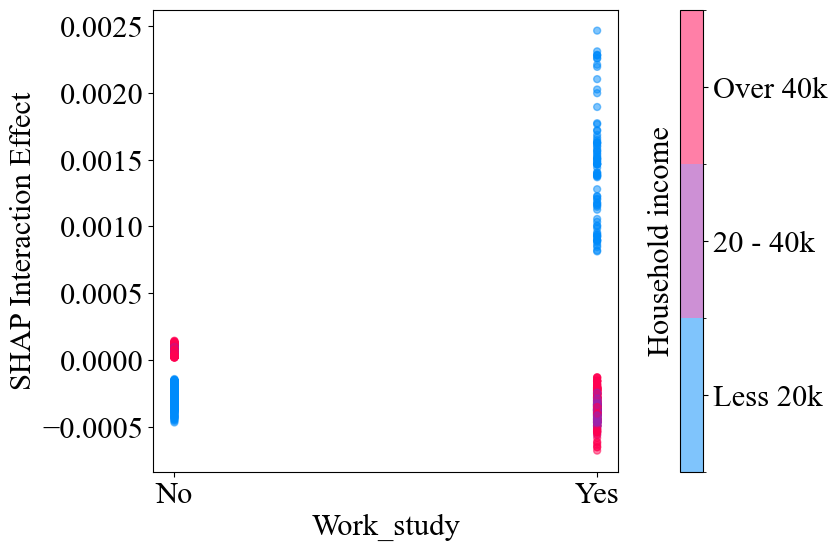

In [20]:
import matplotlib.colors as mcolors
from shap.plots.colors import red_blue
import matplotlib.pyplot as plt

# Set the font family to Times New Roman for the entire plot
plt.rcParams['font.family'] = 'Times New Roman'

feature1 = 'Work_study'
feature2 = 'Household income'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0), red_blue(0.5), red_blue(1 - np.finfo(float).eps)]
cmap = mcolors.ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5] # Boundaries for categories 1,2,3
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xticks([0, 1], ['No', 'Yes'])
#plt.title(f"Interaction: {feature1} and {feature2}")
plt.xlabel(f"{feature1}")
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([1, 2, 3])
cbar.set_label(f"{feature2}")
cbar.ax.set_yticklabels(['Less 20k', '20 - 40k', 'Over 40k'])
cbar.ax.yaxis.set_label_position('left')
# Save plot with high resolution
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()

Plot saved to shap_outputs\interactions\interaction_Shopping_and_Household income.pdf


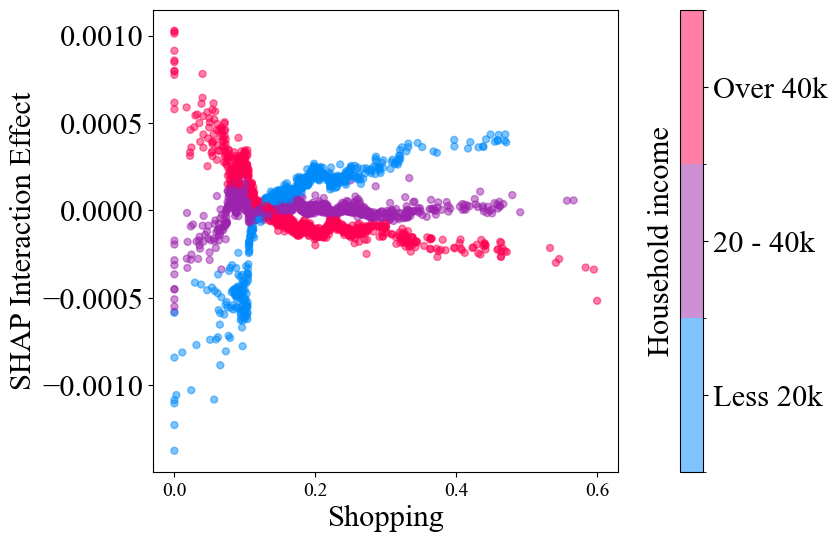

In [22]:
import matplotlib.colors as mcolors
from shap.plots.colors import red_blue
# Set the font family to Times New Roman for the entire plot
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Shopping'
feature2 = 'Household income'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise


plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values

colors = [red_blue(0), red_blue(0.5), red_blue(1 - np.finfo(float).eps)]
cmap = mcolors.ListedColormap(colors)


bounds = [0.5, 1.5, 2.5, 3.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xticks(fontsize=14)

#plt.title(f"Interaction: {feature1} and {feature2}", fontsize=14)
plt.xlabel(f"{feature1}")
plt.ylabel("SHAP Interaction Effect")

cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([1, 2, 3]) 
cbar.set_label(f"{feature2}")
cbar.ax.set_yticklabels(['Less 20k', '20 - 40k', 'Over 40k']) 
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()

output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()


Plot saved to shap_outputs\interactions\interaction_Restaurant_and_Age.pdf


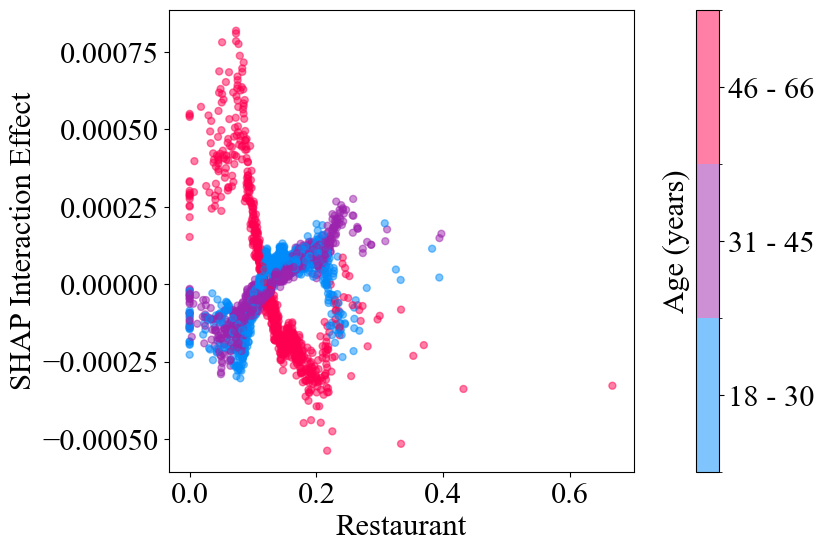

In [24]:
import matplotlib.colors as mcolors
# Set the font family to Times New Roman for the entire plot
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Restaurant'
feature2 = 'Age'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0), red_blue(0.5), red_blue(1 - np.finfo(float).eps)]
cmap = mcolors.ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5]  
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
#plt.title(f"Interaction: {feature1} and {feature2}", fontsize=14)
plt.xlabel(f"{feature1}")
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([1, 2, 3])  
cbar.set_label(f"{feature2} (years)")
cbar.ax.set_yticklabels(['18 - 30', '31 - 45', '46 - 66'])  
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()


Plot saved to shap_outputs\interactions\interaction_Industry_and_Age.pdf


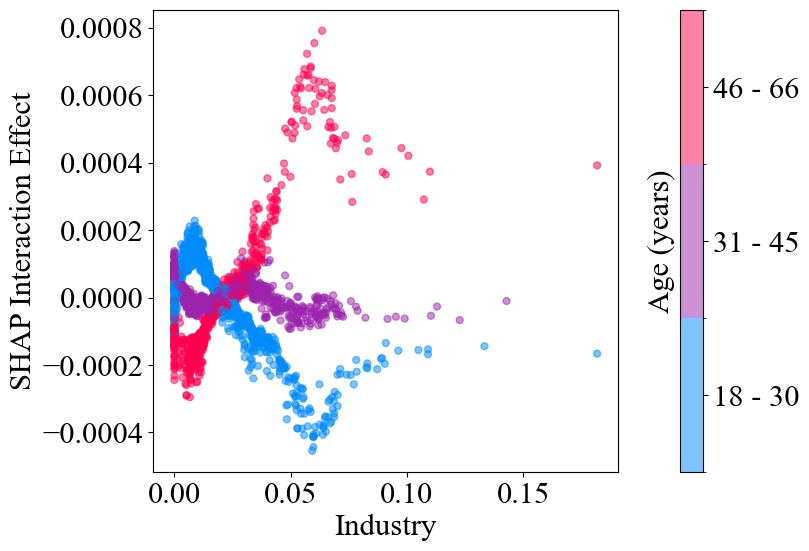

In [25]:
import matplotlib.colors as mcolors
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Industry'
feature2 = 'Age'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise

plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values

colors = [red_blue(0), red_blue(0.5), red_blue(1 - np.finfo(float).eps)]  
cmap = mcolors.ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5]  
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
#plt.title(f"Interaction: {feature1} and {feature2}", fontsize=14)
plt.xlabel(f"{feature1}")
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([1, 2, 3])  
cbar.set_label(f"{feature2} (years)")
cbar.ax.set_yticklabels(['18 - 30', '31 - 45', '46 - 66'])  
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()

output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()


Plot saved to shap_outputs\interactions\interaction_Time hour_and_Gender.pdf


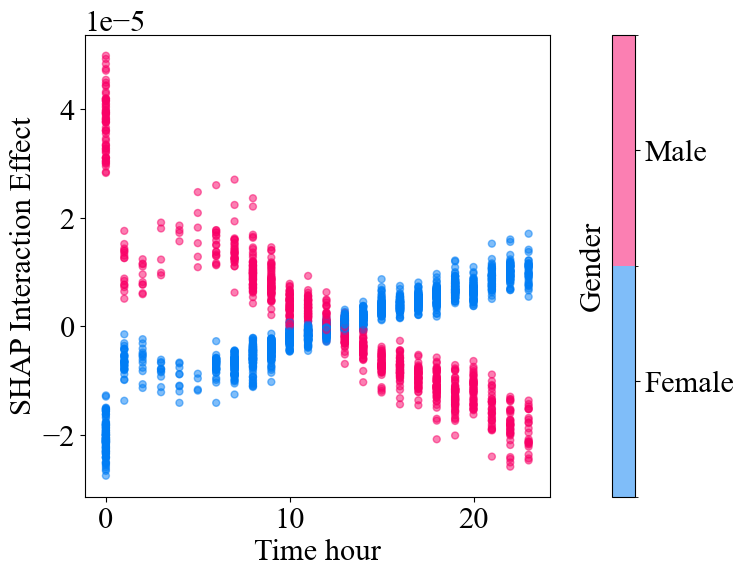

In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
from shap.plots.colors import red_blue
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Time hour'
feature2 = 'Gender'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0.1), red_blue(0.9)]  
cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5]  # Boundaries for two categories
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xlabel(feature1)
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([0, 1])  # Ticks for two categories
cbar.set_label(feature2)
cbar.ax.set_yticklabels(['Female', 'Male'])  # Custom labels
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight') 
print(f"Plot saved to {output_path}")
plt.show()


Plot saved to shap_outputs\interactions\interaction_Location types_and_Gender.pdf


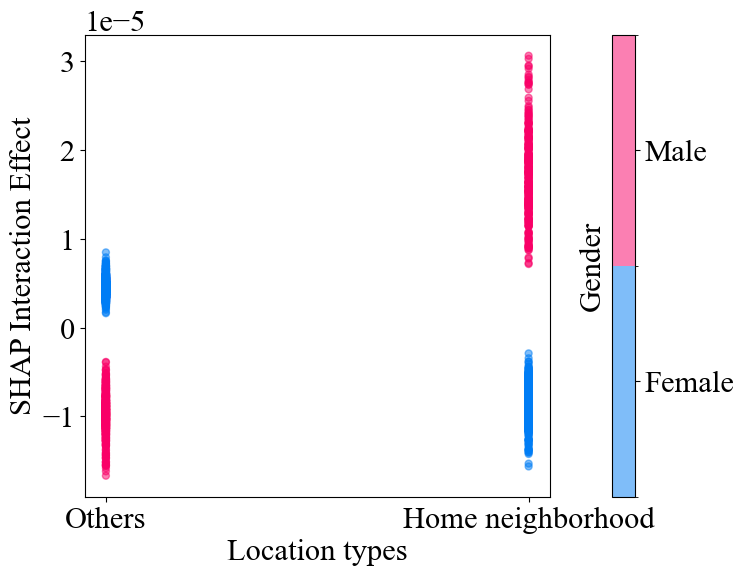

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
from shap.plots.colors import red_blue
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Location types'
feature2 = 'Gender'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0.1), red_blue(0.9)]
cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xticks([0, 1], ['Others', 'Home neighborhood'])
#plt.title(f"Interaction: {feature1} and {feature2}", fontsize=14)
plt.xlabel(feature1)
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([0, 1]) # Ticks for two categories
cbar.set_label(feature2)
cbar.ax.set_yticklabels(['Female', 'Male']) # Custom labels
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {ouput_path}")
plt.show()

Plot saved to shap_outputs\interactions\interaction_Work_study_and_Education level.pdf


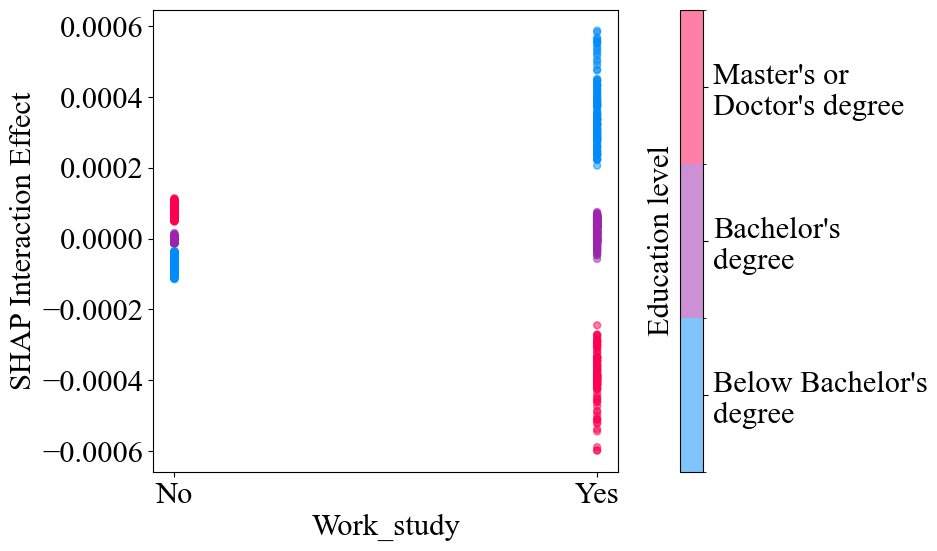

In [28]:
import matplotlib.colors as mcolors
from shap.plots.colors import red_blue
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Work_study'
feature2 = 'Education level'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0), red_blue(0.5), red_blue(1 - np.finfo(float).eps)]  
cmap = mcolors.ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xticks([0, 1], ['No', 'Yes'])
#plt.title(f"Interaction: {feature1} and {feature2}", fontsize=14)
plt.xlabel(f"{feature1}")
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([1, 2, 3]) 
cbar.set_label(f"{feature2}")
cbar.ax.set_yticklabels(["Below Bachelor's\ndegree",
                   "Bachelor's\ndegree",
                   "Master's or\nDoctor's degree"]) 
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()


Plot saved to shap_outputs\interactions\interaction_Company_and_Education level.pdf


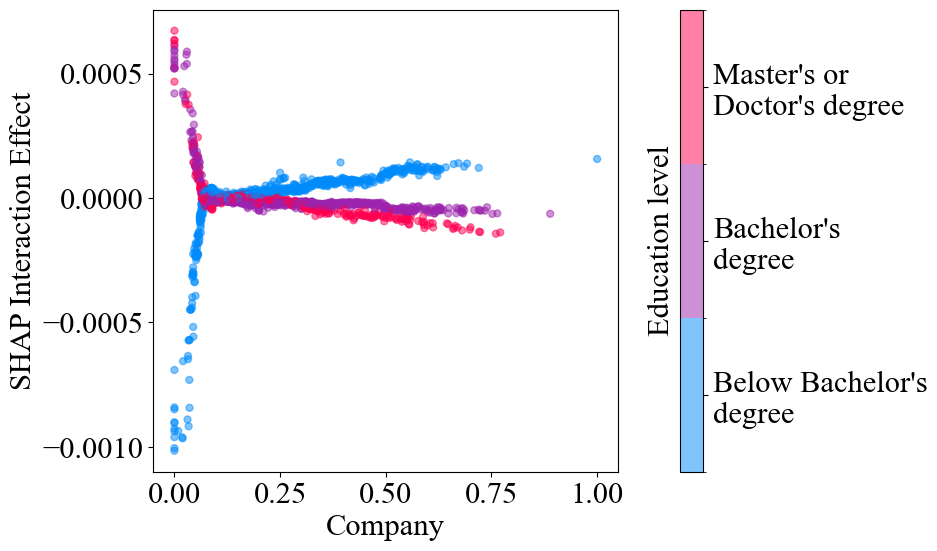

In [29]:
import matplotlib.colors as mcolors
from shap.plots.colors import red_blue
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Company'
feature2 = 'Education level'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0), red_blue(0.5), red_blue(1 - np.finfo(float).eps)]  
cmap = mcolors.ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5]  # Boundaries for categories 1,2,3
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
#plt.title(f"Interaction: {feature1} and {feature2}", fontsize=14)
plt.xlabel(f"{feature1}")
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([1, 2, 3])
cbar.set_label(f"{feature2}")
cbar.ax.set_yticklabels(["Below Bachelor's\ndegree",
                   "Bachelor's\ndegree",
                   "Master's or\nDoctor's degree"])
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()


Plot saved to shap_outputs\interactions\interaction_Time hour_and_Employment status.pdf


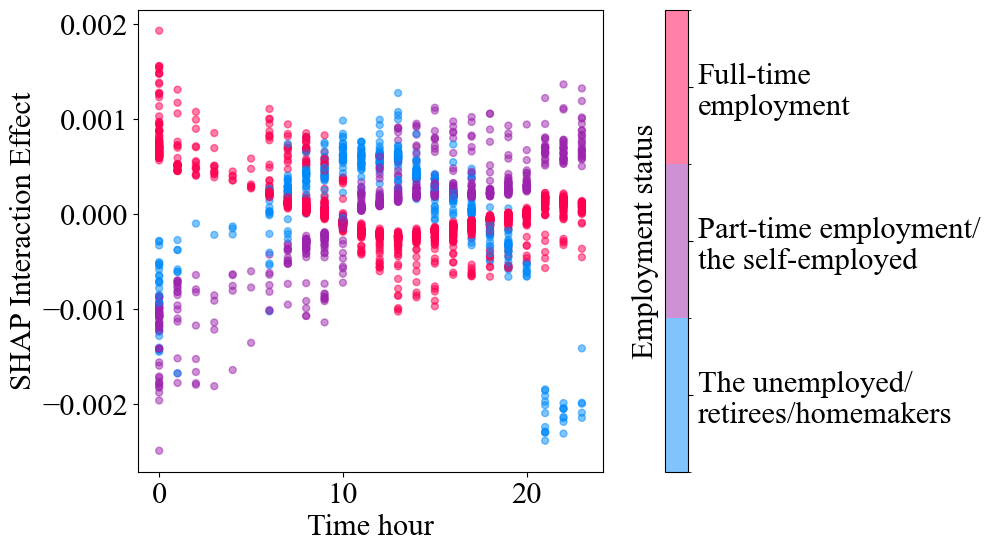

In [30]:
import matplotlib.colors as mcolors
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Time hour'
feature2 = 'Employment status'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0), red_blue(0.5), red_blue(1 - np.finfo(float).eps)]  # Discrete colors
cmap = mcolors.ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
#plt.title(f"Interaction: {feature1} and {feature2}", fontsize=14)
plt.xlabel(f"{feature1}")
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([1, 2, 3]) 
cbar.set_label(f"{feature2}")
cbar.ax.set_yticklabels(['The unemployed/\nretirees/homemakers',
                   'Part-time employment/\nthe self-employed',
                   'Full-time\nemployment'])  # Custom labels
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()

Plot saved to shap_outputs\interactions\interaction_Industry_and_Employment status.pdf


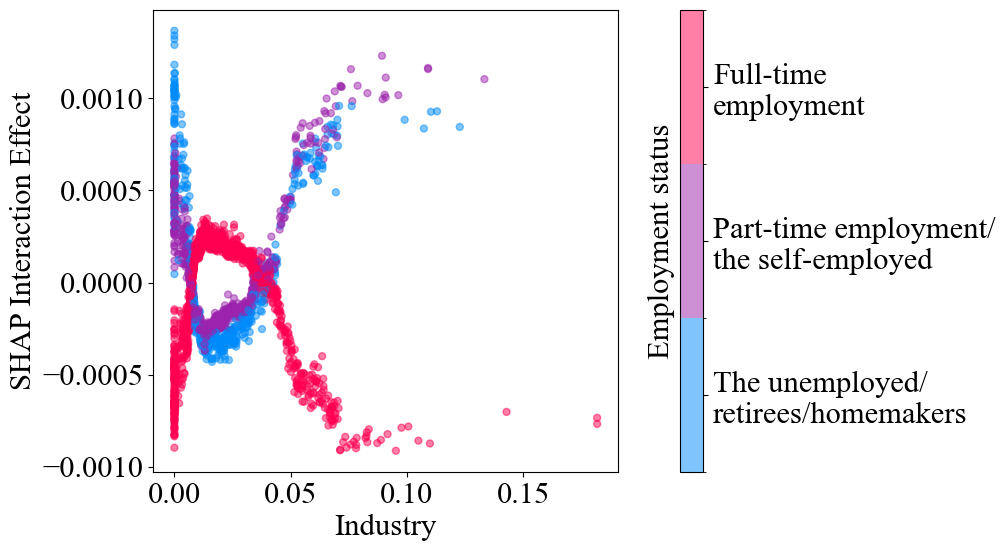

In [31]:
import matplotlib.colors as mcolors
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Industry'
feature2 = 'Employment status'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values

colors = [red_blue(0), red_blue(0.5), red_blue(1 - np.finfo(float).eps)] 
cmap = mcolors.ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5] 
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
# Customize plot
#plt.title(f"Interaction: {feature1} and {feature2}", fontsize=14)
plt.xlabel(f"{feature1}")
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([1, 2, 3])
cbar.set_label(f"{feature2}")
cbar.ax.set_yticklabels(['The unemployed/\nretirees/homemakers',
                   'Part-time employment/\nthe self-employed',
                   'Full-time\nemployment'])  # Custom labels
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()

# Save plot with high resolution
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()

Plot saved to shap_outputs\interactions\interaction_Location types_and_Work_study.pdf


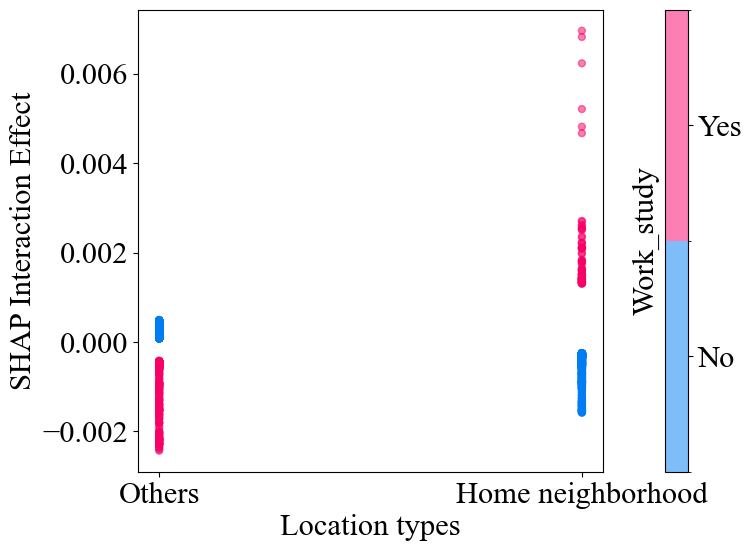

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
from shap.plots.colors import red_blue
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Location types'
feature2 = 'Work_study'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0.1), red_blue(0.9)]  
cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5]  # Boundaries for two categories
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xticks([0, 1], ['Others', 'Home neighborhood'])
plt.xlabel(feature1)
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([0, 1])  # Ticks for two categories
cbar.set_label(feature2)
cbar.ax.set_yticklabels(['No', 'Yes'])  # Custom labels
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()

Plot saved to shap_outputs\interactions\interaction_Location types_and_Travel.pdf


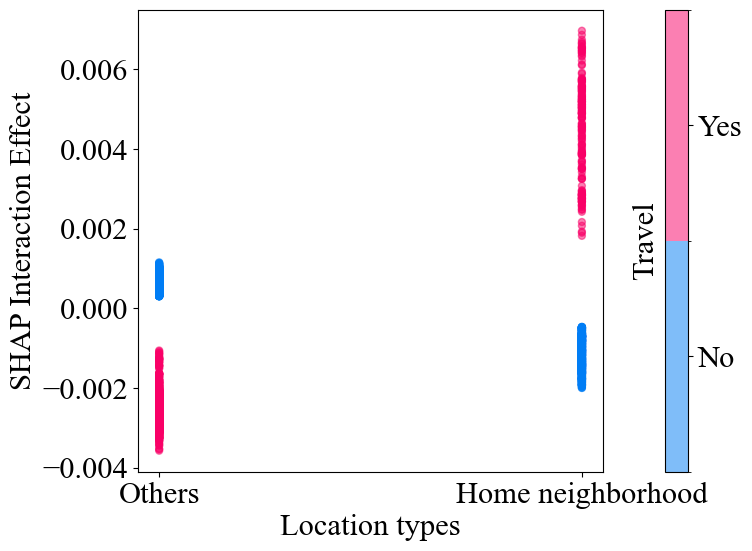

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
from shap.plots.colors import red_blue
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Location types'
feature2 = 'Travel'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0.1), red_blue(0.9)]  # Red and blue from RdBu for consistency
cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5]  # Boundaries for two categories
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xticks([0, 1], ['Others', 'Home neighborhood'])
# Customize plot
plt.xlabel(feature1)
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([0, 1])
cbar.set_label(feature2)
cbar.ax.set_yticklabels(['No', 'Yes'])
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()

Plot saved to shap_outputs\interactions\interaction_Time hour_and_Travel.pdf


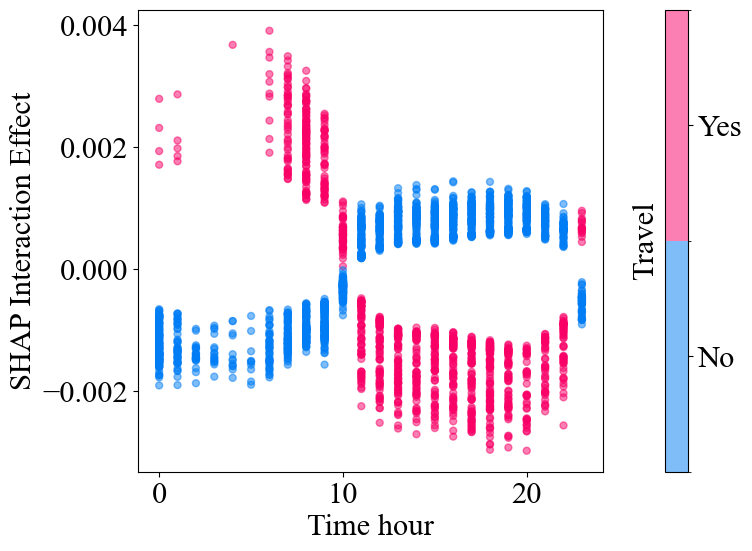

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
from shap.plots.colors import red_blue
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Time hour'
feature2 = 'Travel'

try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise

# Create custom interaction plot to mimic shap.dependence_plot
plt.figure(figsize=(8, 6))
# Scatter plot: x-axis = feature1, y-axis = interaction effects, color = feature2
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0.1), red_blue(0.9)]  # Red and blue from RdBu for consistency
cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5]  # Boundaries for two categories
norm = mcolors.BoundaryNorm(bounds, cmap.N)
# Create scatter plot
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xlabel(feature1)
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([0, 1])
cbar.set_label(feature2)
cbar.ax.set_yticklabels(['No', 'Yes'])  # Custom labels
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()

Plot saved to shap_outputs\interactions\interaction_Time hour_and_Personal affair.pdf


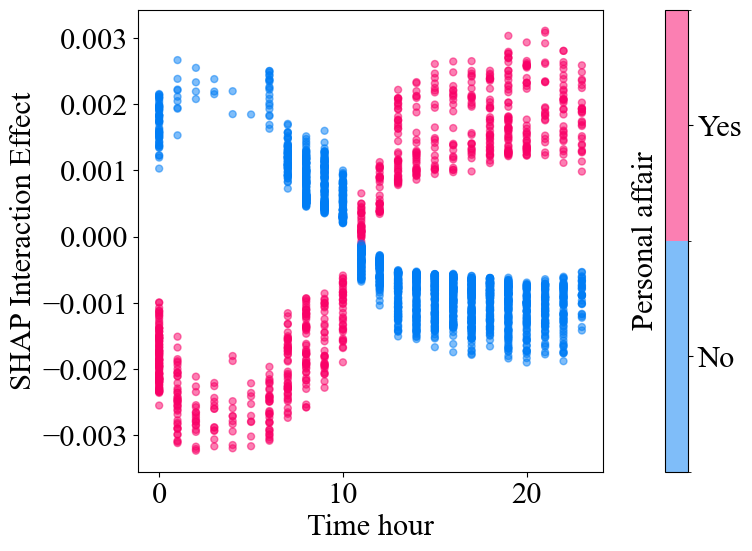

In [13]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
from shap.plots.colors import red_blue
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Time hour'
feature2 = 'Personal affair'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0.1), red_blue(0.9)] 
bounds = [-0.5, 0.5, 1.5]  # Boundaries for two categories
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xlabel(feature1)
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([0, 1]) 
cbar.set_label(feature2)
cbar.ax.set_yticklabels(['No', 'Yes'])  # Custom labels
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()


Plot saved to shap_outputs\interactions\interaction_Time hour_and_Location types.pdf


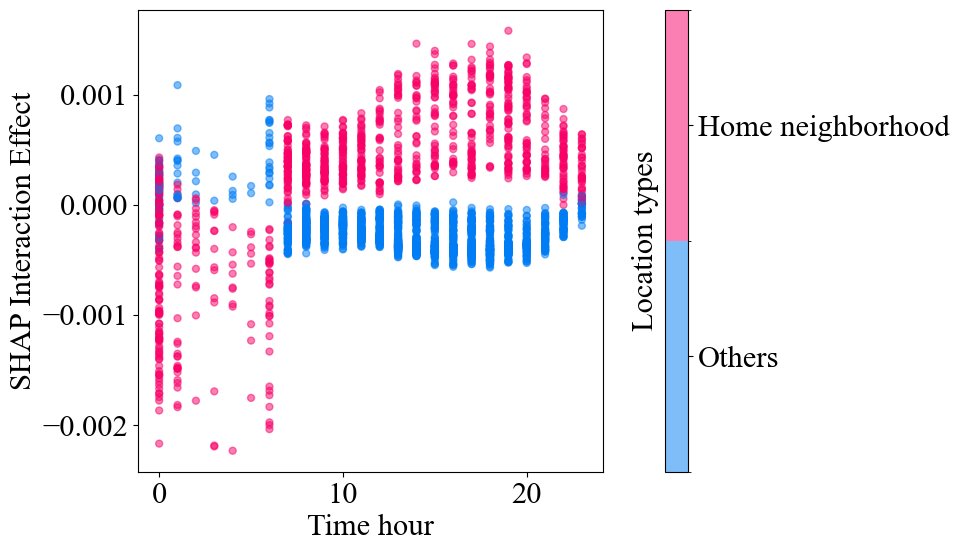

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
from shap.plots.colors import red_blue
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Time hour'
feature2 = 'Location types'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0.1), red_blue(0.9)]
cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5]
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xlabel(feature1)
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([0, 1])
cbar.set_label(feature2)
cbar.ax.set_yticklabels(['Others', 'Home neighborhood'])
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight') 
print(f"Plot saved to {output_path}")
plt.show()

Plot saved to shap_outputs\interactions\interaction_Tree height_and_Location types.pdf


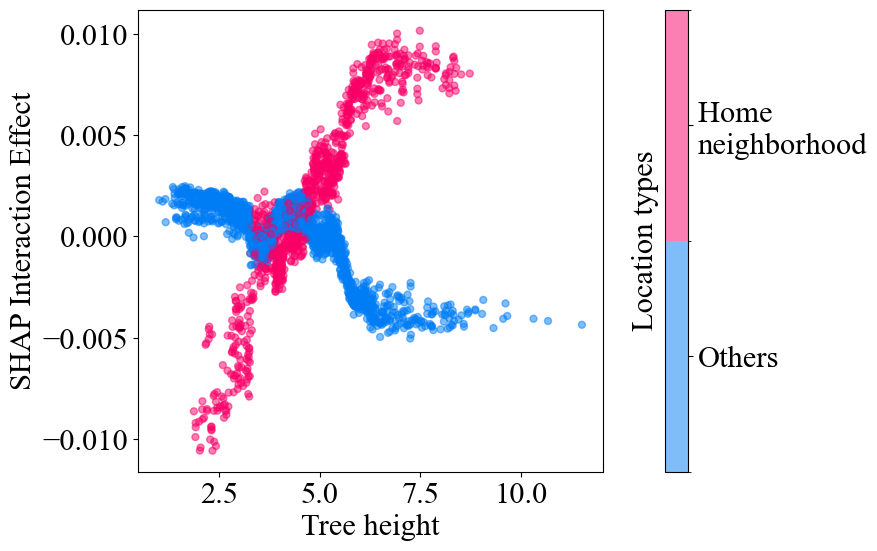

In [19]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
from shap.plots.colors import red_blue
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'Tree height'
feature2 = 'Location types'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0.1), red_blue(0.9)]  # Red and blue from RdBu for consistency
cmap = mcolors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5]  # Boundaries for two categories
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xlabel(feature1)
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([0, 1])  # Ticks for two categories
cbar.set_label(feature2)
cbar.ax.set_yticklabels(['Others', 'Home \nneighborhood'])
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()

Plot saved to shap_outputs\interactions\interaction_POI density_and_Mobility status.pdf


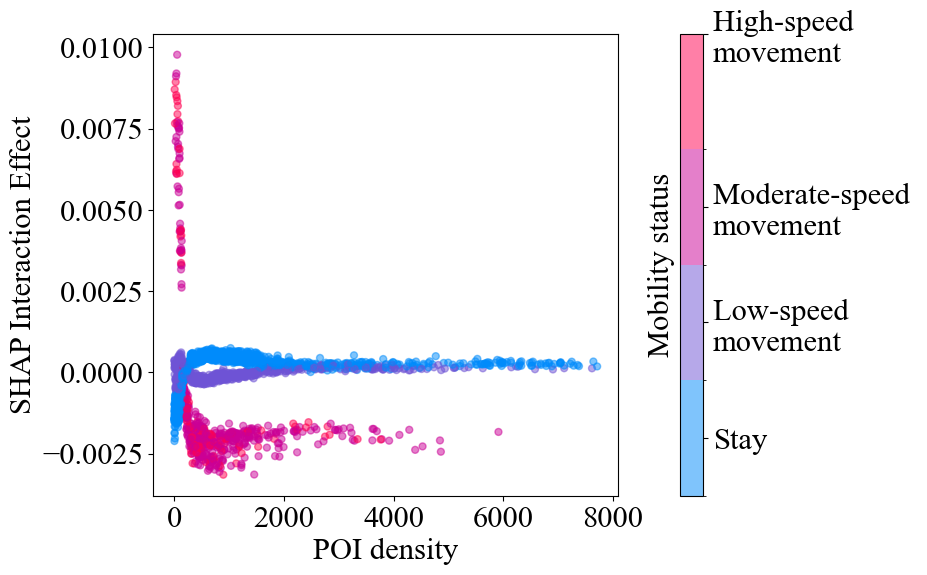

In [17]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from shap.plots.colors import red_blue
import numpy as np
plt.rcParams['font.family'] = 'Times New Roman'
feature1 = 'POI density'
feature2 = 'Mobility status'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2] 
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0), red_blue(0.33), red_blue(0.66), red_blue(1 - np.finfo(float).eps)]
cmap = mcolors.ListedColormap(colors)
bounds = [-0.5,0.5, 1.5, 2.5, 3]
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xlabel(f"{feature1}")
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([0, 1, 2, 3]) 
cbar.set_label(f"{feature2}")
cbar.ax.set_yticklabels(['Stay', 'Low-speed \nmovement', 'Moderate-speed \nmovement', 'High-speed \nmovement'])
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()

Plot saved to shap_outputs\interactions\interaction_Time hour_and_Time inflexibility.pdf


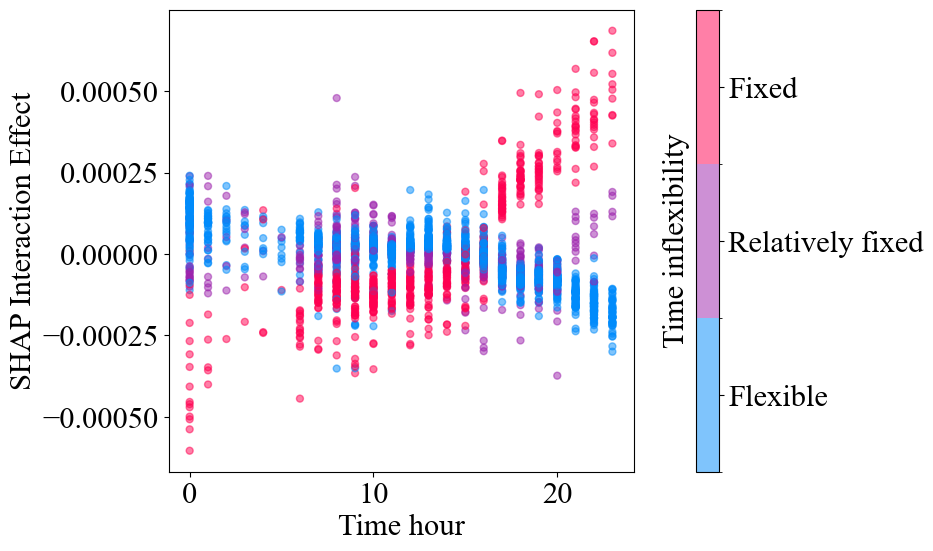

In [18]:
import matplotlib.colors as mcolors
# Specify features for interaction plot
feature1 = 'Time hour'
feature2 = 'Time inflexibility'
plt.rcParams['font.family'] = 'Times New Roman'
try:
    idx1 = feature_names_display.index(feature1)
    idx2 = feature_names_display.index(feature2)
    interaction_vals = interaction_effects_mean[:, idx1, idx2]
except ValueError as e:
    print(f"Error: One or both features ({feature1}, {feature2}) not found in feature_names_display: {str(e)}")
    raise
plt.figure(figsize=(8, 6))
feature1_vals = X_data_sample_df[feature1].values
feature2_vals = X_data_sample_df[feature2].values
colors = [red_blue(0), red_blue(0.5), red_blue(1 - np.finfo(float).eps)]  # Discrete colors
cmap = mcolors.ListedColormap(colors)
bounds = [0.5, 1.5, 2.5, 3.5]  # Boundaries for categories 1,2,3
norm = mcolors.BoundaryNorm(bounds, cmap.N)
sc = plt.scatter(feature1_vals, interaction_vals, c=feature2_vals, cmap=cmap, norm=norm, alpha=0.5, s=25)
plt.xlabel(f"{feature1}")
plt.ylabel("SHAP Interaction Effect")
cbar = plt.colorbar(sc, pad=0.1)
cbar.set_ticks([1, 2, 3])
cbar.set_label(f"{feature2}")
cbar.ax.set_yticklabels(['Flexible',
                   'Relatively fixed',
                   'Fixed'])  # Custom labels
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params()
output_path = os.path.join(interactions_dir, f'interaction_{feature1}_and_{feature2}.pdf')
plt.savefig(output_path, dpi=800, bbox_inches='tight')
print(f"Plot saved to {output_path}")
plt.show()